# Comparing Model-Based vs Model-Free RL

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare model-based and model-free RL
- Understand trade-offs between approaches
- Evaluate sample efficiency
- Choose appropriate approach for problems

## 🔗 Prerequisites

- ✅ Understanding of both model-based and model-free RL
- ✅ Understanding of sample efficiency
- ✅ Python knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Comparing model-based vs model-free approaches

---

## Introduction

**Comparison** between model-based (learn dynamics, plan) and model-free (learn values/policies directly) RL helps choose the right approach for different problems.

## Lesson Brief

This lesson compares two major RL styles: model-based and model-free learning.

Students should focus on the trade-off between faster planning with a model and simpler direct learning without one.

Why this matters: comparison helps students organize the field instead of seeing algorithms as isolated names.

This notebook is about judgment, not only implementation.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 8: Integrating Learning and Planning"**:
[Watch on YouTube](https://www.youtube.com/watch?v=ItMutbeOHtc)

Why this pick:
- Helps students compare learning from raw experience against learning with an internal model.
- Stronger classroom fit than a very short summary video.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Model-based: learns or uses dynamics.
- Model-free: learns directly from experience.
- Sample efficiency: learning from less real data.
- Planning cost: extra compute for reasoning.
- Comparison judgment: deciding which trade-off matters most in a problem.

### Quick Check
- Why can model-based methods need fewer samples?
- Why can model-free still be attractive?
- What trade-off appears in the comparison?
- Why is the best choice problem-dependent rather than universal?

### Common Mistakes
- Assuming model-based is always better.
- Ignoring planning cost.
- Overlooking the damage of poor models.
- Treating the comparison as a simple winner-loser ranking.


## This Comparison Is About Trade-Offs, Not a Winner

Students often want one final answer: which style is better?
This notebook is more useful when it teaches the right question instead.

### Better question

`What matters more in this problem: sample efficiency, planning ability, simplicity, or robustness to model error?`

### Why there is no universal winner

- A good model can make learning faster.
- A bad model can mislead planning.
- Model-free methods avoid explicit model error, but may need more real experience.

### Teaching takeaway

The lesson is not:

`model-based wins`

or

`model-free wins`

The lesson is:

`understand the trade-off, then match the method to the problem.`

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** This cell runs a teaching illustration and shows the result through a comparison plot and a printed table.

**Why this matters:** It turns the abstract trade-off between the two approaches into something students can read visually.

**What to expect in the output:** Expect a synthetic comparison chart and a short summary table, not a benchmark from a full training run.

**Common student confusion:** Students should remember that the curves are illustrative shapes for explanation, not measured results from a real experiment.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nComparing Model-Based vs Model-Free RL")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nComparison Table:")
# Show text or numbers in the cell output area under the code.
print("  Feature           | Model-Based  | Model-Free")
# Show text or numbers in the cell output area under the code.
print("  ------------------|--------------|------------")
# Show text or numbers in the cell output area under the code.
print("  Sample Efficiency | High         | Lower")
# Show text or numbers in the cell output area under the code.
print("  Computation       | High (plan)  | Lower")
# Show text or numbers in the cell output area under the code.
print("  Model Errors      | Sensitive    | Robust")
# Show text or numbers in the cell output area under the code.
print("  Planning          | Yes          | No")
# Show text or numbers in the cell output area under the code.
print("  Flexibility       | Less         | More")

# Show text or numbers in the cell output area under the code.
print("\nModel-Based:")
# Show text or numbers in the cell output area under the code.
print("  - Learn environment model")
# Show text or numbers in the cell output area under the code.
print("  - Plan using model")
# Show text or numbers in the cell output area under the code.
print("  - High sample efficiency")
# Show text or numbers in the cell output area under the code.
print("  - Sensitive to model errors")

# Show text or numbers in the cell output area under the code.
print("\nModel-Free:")
# Show text or numbers in the cell output area under the code.
print("  - Learn values/policies directly")
# Show text or numbers in the cell output area under the code.
print("  - No explicit model")
# Show text or numbers in the cell output area under the code.
print("  - More robust to errors")
# Show text or numbers in the cell output area under the code.
print("  - Lower sample efficiency")

# Show text or numbers in the cell output area under the code.
print("\n✅ Comparison complete!")


✅ Libraries imported!

Comparing Model-Based vs Model-Free RL

Comparison Table:
  Feature           | Model-Based  | Model-Free
  ------------------|--------------|------------
  Sample Efficiency | High         | Lower
  Computation       | High (plan)  | Lower
  Model Errors      | Sensitive    | Robust
  Planning          | Yes          | No
  Flexibility       | Less         | More

Model-Based:
  - Learn environment model
  - Plan using model
  - High sample efficiency
  - Sensitive to model errors

Model-Free:
  - Learn values/policies directly
  - No explicit model
  - More robust to errors
  - Lower sample efficiency

✅ Comparison complete!


## Worked Example: Comparing Two Learning Styles

This notebook compares the *reasoning pattern* of:

- **model-free RL**: learn values or policies directly from experience
- **model-based RL**: learn or use a model of dynamics, then plan with it

The goal here is conceptual clarity and a small simulation, not a full production implementation.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


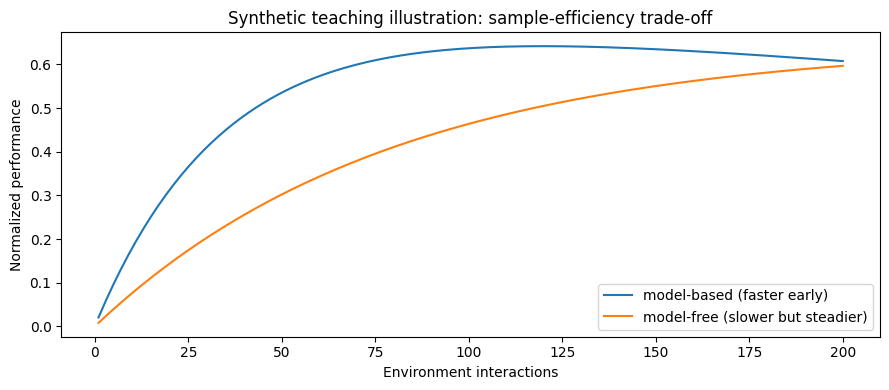

Comparison table (teaching summary):

Feature | Model-based | Model-free
--------------------------------------------------
sample efficiency | higher | lower
planning | yes | no
sensitivity to model error | higher | lower
implementation simplicity | lower | higher

Teaching point:
This figure is a conceptual illustration of the trade-off, not an empirical leaderboard.
Model-based methods often learn faster from fewer samples because they plan,
but they can fail when the learned model is inaccurate.


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
steps = np.arange(1, 201)

# Synthetic teaching curves: these are illustrative shapes, not results from a benchmark run.
# Save a value in a name so the next lines can read it.
model_based_curve = 0.75 * (1 - np.exp(-steps / 35)) - 0.0007 * steps
# Another assignment—same idea: store a value for the lines below.
model_free_curve = 0.65 * (1 - np.exp(-steps / 80))

# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(9, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(steps, model_based_curve, label="model-based (faster early)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(steps, model_free_curve, label="model-free (slower but steadier)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Environment interactions")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Normalized performance")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Synthetic teaching illustration: sample-efficiency trade-off")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Save a value in a name so the next lines can read it.
comparison = {
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "sample efficiency": ("higher", "lower"),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "planning": ("yes", "no"),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "sensitivity to model error": ("higher", "lower"),
    # One key/value row inside a dict literal (domain -> fields or nested table).
    "implementation simplicity": ("lower", "higher"),
# Part of a dict/set literal layout (syntax grouping).
}

# Show text or numbers in the cell output area under the code.
print("Comparison table (teaching summary):\n")
# Show text or numbers in the cell output area under the code.
print("Feature | Model-based | Model-free")
# Show text or numbers in the cell output area under the code.
print("-" * 50)
# Start a loop: repeat the indented block once per item in the sequence.
for feature, (mb, mf) in comparison.items():
    # Show text or numbers in the cell output area under the code.
    print(f"{feature} | {mb} | {mf}")

# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("This figure is a conceptual illustration of the trade-off, not an empirical leaderboard.")
# Show text or numbers in the cell output area under the code.
print("Model-based methods often learn faster from fewer samples because they plan,")
# Show text or numbers in the cell output area under the code.
print("but they can fail when the learned model is inaccurate.")


In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


## Summary

This notebook compared two major RL styles:

- **model-based RL** learns or uses a dynamics model and plans with it
- **model-free RL** learns directly from experience without an explicit model

### Main takeaway

The trade-off is usually:

- faster learning and more planning power for model-based methods
- simpler and often more robust learning for model-free methods

### Practical question to ask

If environment interactions are expensive, model-based RL becomes more attractive.
If modeling the environment is very hard or unreliable, model-free RL may be safer.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


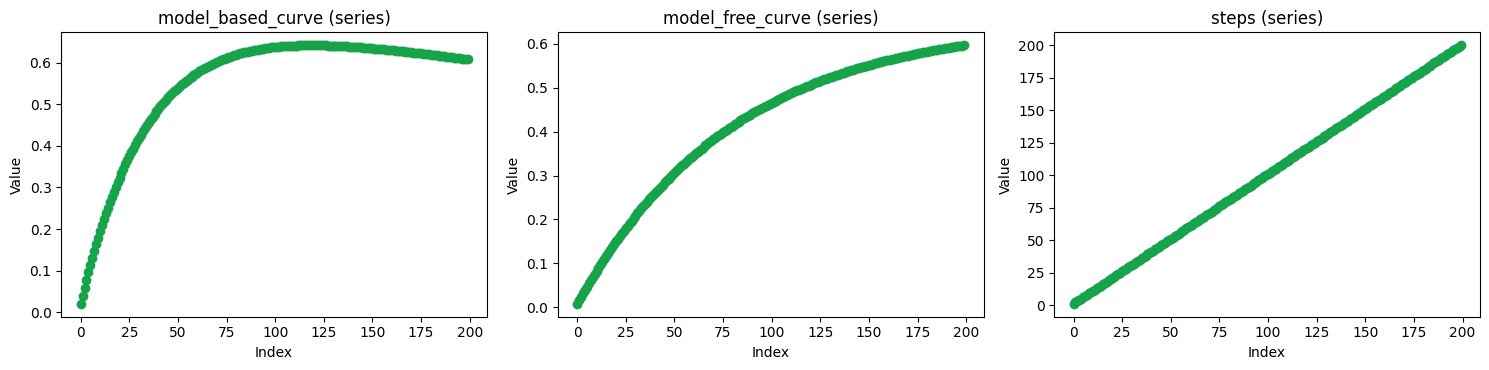

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Model-based and model-free methods make different trade-offs between planning ability, sample efficiency, and modeling complexity.

**If students remember one idea:** The right approach depends on what is expensive: collecting data, building a model, or tolerating planning errors.

**Quick check before moving on:**
- Can you explain when model-based RL may learn faster than model-free RL?
- Can you describe when model-free methods may be simpler or more robust?

**Bridge to the next step:** The final lesson in this unit broadens the idea of policy learning by conditioning behavior on a goal.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=11 | term=True | trunc=False


objc[77842]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1144b0138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1149ac9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77842]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1144b0188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1149aca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77842]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x1144afc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1149aca68). T

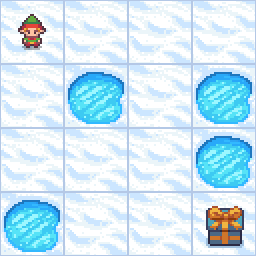

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
